In [ ]:
# 01_data_exploration_and_feature_engineering.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [ ]:
import pandas as pd

beneficiary = pd.read_csv("Train_Beneficiarydata-1542865627584.csv")
inpatient = pd.read_csv("Train_Inpatientdata-1542865627584.csv")
outpatient = pd.read_csv("Train_Outpatientdata-1542865627584.csv")
labels = pd.read_csv("Train-1542865627584.csv")   # This is your Provider + PotentialFraud file

beneficiary.head(), inpatient.head(), outpatient.head(), labels.head()

(      BeneID         DOB  DOD  Gender  Race RenalDiseaseIndicator  State  \
 0  BENE11001  1943-01-01  NaN       1     1                     0     39   
 1  BENE11002  1936-09-01  NaN       2     1                     0     39   
 2  BENE11003  1936-08-01  NaN       1     1                     0     52   
 3  BENE11004  1922-07-01  NaN       1     1                     0     39   
 4  BENE11005  1935-09-01  NaN       1     1                     0     24   
 
    County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ChronicCond_Alzheimer  \
 0     230                   12                   12                      1   
 1     280                   12                   12                      2   
 2     590                   12                   12                      1   
 3     270                   12                   12                      1   
 4     680                   12                   12                      2   
 
    ChronicCond_Heartfailure  ChronicCond_KidneyDisease  Chr

In [ ]:
print("Beneficiary:", beneficiary.shape)
print("Inpatient:", inpatient.shape)
print("Outpatient:", outpatient.shape)
print("Labels:", labels.shape)

Beneficiary: (138556, 25)
Inpatient: (40474, 30)
Outpatient: (517737, 27)
Labels: (5410, 2)


In [ ]:
print("Beneficiary Columns:\n", beneficiary.columns.tolist(), "\n")
print("Inpatient Columns:\n", inpatient.columns.tolist(), "\n")
print("Outpatient Columns:\n", outpatient.columns.tolist(), "\n")
print("Labels Columns:\n", labels.columns.tolist(), "\n")

Beneficiary Columns:
 ['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov', 'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure', 'ChronicCond_KidneyDisease', 'ChronicCond_Cancer', 'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression', 'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart', 'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis', 'ChronicCond_stroke', 'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt'] 

Inpatient Columns:
 ['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCo

In [ ]:
beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


In [ ]:
def missing_report(df):
    return (df.isna().mean()*100).sort_values(ascending=False)

print("Beneficiary Missing Values:\n", missing_report(beneficiary).head(20), "\n")
print("Inpatient Missing Values:\n", missing_report(inpatient).head(20), "\n")
print("Outpatient Missing Values:\n", missing_report(outpatient).head(20), "\n")
print("Labels Missing Values:\n", missing_report(labels).head(20))

Beneficiary Missing Values:
 DOD                                98.974422
BeneID                              0.000000
DOB                                 0.000000
Gender                              0.000000
Race                                0.000000
RenalDiseaseIndicator               0.000000
State                               0.000000
County                              0.000000
NoOfMonths_PartACov                 0.000000
NoOfMonths_PartBCov                 0.000000
ChronicCond_Alzheimer               0.000000
ChronicCond_Heartfailure            0.000000
ChronicCond_KidneyDisease           0.000000
ChronicCond_Cancer                  0.000000
ChronicCond_ObstrPulmonary          0.000000
ChronicCond_Depression              0.000000
ChronicCond_Diabetes                0.000000
ChronicCond_IschemicHeart           0.000000
ChronicCond_Osteoporasis            0.000000
ChronicCond_rheumatoidarthritis     0.000000
dtype: float64 

Inpatient Missing Values:
 ClmProcedureCode_6     100.

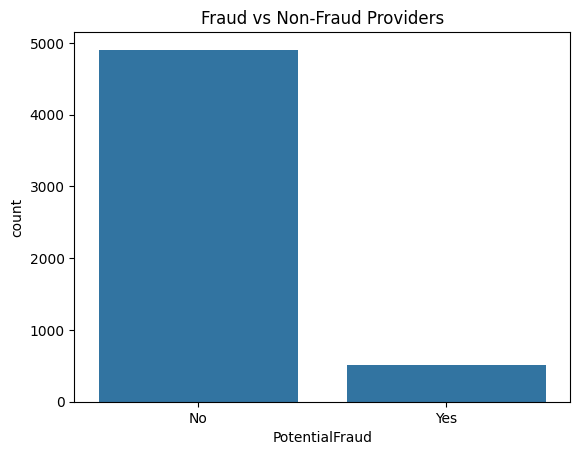

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=labels, x='PotentialFraud')
plt.title("Fraud vs Non-Fraud Providers")
plt.show()

In [ ]:
# Inpatient claim counts per provider
inpatient_agg = inpatient.groupby("Provider").agg(
    inpatient_claim_count = ("ClaimID", "count"),
    inpatient_total_reimbursement = ("InscClaimAmtReimbursed", "sum"),
    inpatient_avg_reimbursement = ("InscClaimAmtReimbursed", "mean"),
    inpatient_unique_beneficiaries = ("BeneID", "nunique")
).reset_index()

In [ ]:
outpatient_agg = outpatient.groupby("Provider").agg(
    outpatient_claim_count = ("ClaimID", "count"),
    outpatient_total_reimbursement = ("InscClaimAmtReimbursed", "sum"),
    outpatient_avg_reimbursement = ("InscClaimAmtReimbursed", "mean"),
    outpatient_unique_beneficiaries = ("BeneID", "nunique")
).reset_index()

In [ ]:
provider_features = inpatient_agg.merge(
    outpatient_agg, on="Provider", how="outer"
)

In [ ]:
provider_features = provider_features.fillna(0)

In [ ]:
# Identify chronic condition columns
chronic_cols = [c for c in beneficiary.columns if c.startswith("ChronicCond_")]

# Count chronic conditions per beneficiary
beneficiary["chronic_count"] = beneficiary[chronic_cols].sum(axis=1)

# Age (if DOB exists)
if "DOB" in beneficiary.columns:
    beneficiary["DOB"] = pd.to_datetime(beneficiary["DOB"])
    beneficiary["age"] = 2009 - beneficiary["DOB"].dt.year
else:
    beneficiary["age"] = np.nan

# Death flag
if "DOD" in beneficiary.columns:
    beneficiary["DOD"] = pd.to_datetime(beneficiary["DOD"])
    beneficiary["is_dead"] = beneficiary["DOD"].notna().astype(int)
else:
    beneficiary["is_dead"] = 0

# Provider-beneficiary mapping
ip_pb = inpatient[["Provider", "BeneID"]].drop_duplicates()
op_pb = outpatient[["Provider", "BeneID"]].drop_duplicates()
prov_bene = pd.concat([ip_pb, op_pb]).drop_duplicates()

bene_with_features = prov_bene.merge(
    beneficiary[["BeneID", "chronic_count", "age", "is_dead"]],
    on="BeneID",
    how="left"
)

prov_bene_agg = bene_with_features.groupby("Provider").agg(
    avg_bene_chronic_count=("chronic_count", "mean"),
    max_bene_chronic_count=("chronic_count", "max"),
    avg_bene_age=("age", "mean"),
    death_rate=("is_dead", "mean"),
    bene_count=("BeneID", "nunique")
).reset_index()

In [ ]:
provider_features = provider_features.merge(
    prov_bene_agg, on="Provider", how="left"
).fillna(0)

In [ ]:
diag_cols_ip = [c for c in inpatient.columns if "ClmDiagnosisCode" in c]
diag_cols_op = [c for c in outpatient.columns if "ClmDiagnosisCode" in c]

diag_long = pd.concat([
    inpatient.melt(id_vars=["Provider"], value_vars=diag_cols_ip, value_name="DiagCode"),
    outpatient.melt(id_vars=["Provider"], value_vars=diag_cols_op, value_name="DiagCode")
])

diag_long = diag_long.dropna()
diag_agg = diag_long.groupby("Provider")["DiagCode"].nunique().reset_index(name="n_unique_diag_codes")

provider_features = provider_features.merge(diag_agg, on="Provider", how="left").fillna(0)

In [ ]:
proc_cols_ip = [c for c in inpatient.columns if "ClmProcedureCode" in c]
proc_cols_op = [c for c in outpatient.columns if "ClmProcedureCode" in c]

proc_long = pd.concat([
    inpatient.melt(id_vars=["Provider"], value_vars=proc_cols_ip, value_name="ProcCode"),
    outpatient.melt(id_vars=["Provider"], value_vars=proc_cols_op, value_name="ProcCode")
])

proc_long = proc_long.dropna()
proc_agg = proc_long.groupby("Provider")["ProcCode"].nunique().reset_index(name="n_unique_proc_codes")

provider_features = provider_features.merge(proc_agg, on="Provider", how="left").fillna(0)

In [ ]:
provider_features["total_claim_count"] = (
    provider_features["inpatient_claim_count"] + provider_features["outpatient_claim_count"]
)

provider_features["ip_claim_ratio"] = np.where(
    provider_features["total_claim_count"] > 0,
    provider_features["inpatient_claim_count"] / provider_features["total_claim_count"],
    0
)

provider_features["avg_reimbursement_overall"] = np.where(
    provider_features["total_claim_count"] > 0,
    (provider_features["inpatient_total_reimbursement"] + provider_features["outpatient_total_reimbursement"])
    / provider_features["total_claim_count"],
    0
)

In [ ]:
labels["Fraud"] = labels["PotentialFraud"].map({"Yes": 1, "No": 0})

final_df = provider_features.merge(labels[["Provider", "Fraud"]], on="Provider", how="left").fillna(0)

In [ ]:
final_df.to_csv("final_provider_dataset.csv", index=False)
final_df.head()

,Provider,inpatient_claim_count,inpatient_total_reimbursement,inpatient_avg_reimbursement,inpatient_unique_beneficiaries,outpatient_claim_count,outpatient_total_reimbursement,outpatient_avg_reimbursement,outpatient_unique_beneficiaries,avg_bene_chronic_count,max_bene_chronic_count,avg_bene_age,death_rate,bene_count,n_unique_diag_codes,n_unique_proc_codes,total_claim_count,ip_claim_ratio,avg_reimbursement_overall,Fraud
0,PRV51001,5.0,97000.0,19400.000000,5.0,20.0,7640.0,382.000000,19.0,16.458333,21,78.125000,0.000000,24,72.0,3.0,25.0,0.200000,4185.600000,0
1,PRV51003,62.0,573000.0,9241.935484,53.0,70.0,32670.0,466.714286,66.0,17.632479,22,68.957265,0.008547,117,365.0,39.0,132.0,0.469697,4588.409091,1
2,PRV51004,0.0,0.0,0.000000,0.0,149.0,52170.0,350.134228,138.0,17.681159,22,72.485507,0.007246,138,267.0,0.0,149.0,0.000000,350.134228,0
3,PRV51005,0.0,0.0,0.000000,0.0,1165.0,280910.0,241.124464,495.0,18.115152,22,69.987879,0.006061,495,1294.0,0.0,1165.0,0.000000,241.124464,1
4,PRV51007,3.0,19000.0,6333.333333,3.0,69.0,14710.0,213.188406,56.0,18.120690,22,67.982759,0.017241,58,165.0,1.0,72.0,0.041667,468.194444,0
